In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn import metrics

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [17]:
df = pd.read_csv('train2.csv')
df = df.drop(['id'],axis=1)
df = df[df['Status'] != 'Y'] # ← noto'g'ri yozilgan qatorlarni olib tashlash
x = df.drop('Status', axis=1)
y = df['Status']
df.head()

,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status
0,999,D-penicillamine,21532,M,N,N,N,N,2.3,316.0,3.35,172.0,1601.0,179.80,63.0,394.0,9.7,3.0,D
1,2574,Placebo,19237,F,N,N,N,N,0.9,364.0,3.54,63.0,1440.0,134.85,88.0,361.0,11.0,3.0,C
2,3428,Placebo,13727,F,N,Y,Y,Y,3.3,299.0,3.55,131.0,1029.0,119.35,50.0,199.0,11.7,4.0,D
3,2576,Placebo,18460,F,N,N,N,N,0.6,256.0,3.50,58.0,1653.0,71.30,96.0,269.0,10.7,3.0,C
4,788,Placebo,16658,F,N,Y,N,N,1.1,346.0,3.65,63.0,1181.0,125.55,96.0,298.0,10.6,4.0,C


In [18]:
cat = x.select_dtypes(include=['object']).columns.to_list()
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', OneHotEncoder(handle_unknown='ignore'))
])

num = x.select_dtypes(include=['float64']).columns.to_list()
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', StandardScaler())
])

proc = ColumnTransformer([
    ('categorical', cat_pipeline, cat),
    ('numerical', num_pipeline, num)
])

x_prepared = proc.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(x_prepared, y, test_size=0.2, random_state=42)

In [19]:
l_en = LabelEncoder()
y = l_en.fit_transform(y)
# Natija: 'C'→0, 'CL'→1, 'D'→2

              precision    recall  f1-score   support

           C       0.79      0.91      0.85       966
          CL       0.00      0.00      0.00        52
           D       0.78      0.64      0.70       563

    accuracy                           0.79      1581
   macro avg       0.52      0.52      0.52      1581
weighted avg       0.76      0.79      0.77      1581

Model aniqligi: 0.7862112586970272
Log Loss: 0.0


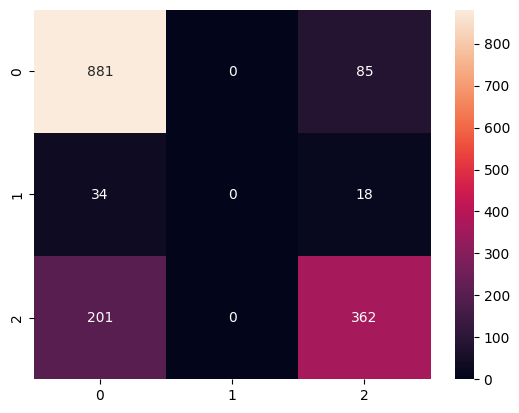

In [20]:
# Train model
lr_model = LogisticRegression(max_iter=5000)
lr_model.fit(x_train, y_train)

# Prediction
y_pred = lr_model.predict(x_test)
y_proba = lr_model.predict_proba(x_test)

# Classification report
lr_model_report = metrics.classification_report(y_test, y_pred, zero_division=0)
lr_model_accuracy = metrics.accuracy_score(y_test, y_pred)
print(lr_model_report)
print("Model aniqligi:", lr_model_accuracy)

# Log Loss
print("Log Loss:", metrics.log_loss(y_test, y_proba, labels=[0, 1, 2]))

# Consufion Matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt="g")
plt.show()

              precision    recall  f1-score   support

           C       0.81      0.92      0.86       966
          CL       0.50      0.02      0.04        52
           D       0.79      0.68      0.73       563

    accuracy                           0.80      1581
   macro avg       0.70      0.54      0.54      1581
weighted avg       0.79      0.80      0.79      1581

Model aniqligi: 0.8020240354206198
Log Loss: 0.0


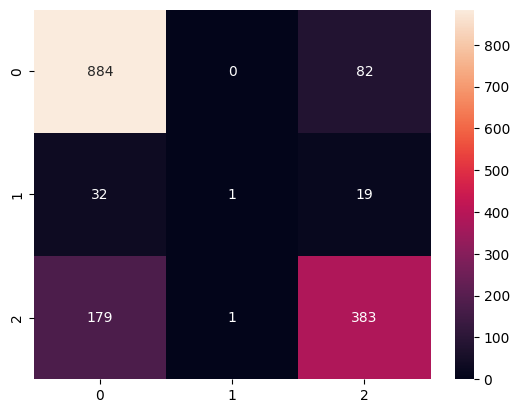

In [21]:
# Train model
svm = SVC(probability=True)
svm.fit(x_train, y_train)

# Prediction
y_pred = svm.predict(x_test)
y_proba = svm.predict_proba(x_test)

# Classification report
svm_report = metrics.classification_report(y_test, y_pred, zero_division=0)
svm_accuracy = metrics.accuracy_score(y_test, y_pred)
print(svm_report)
print("Model aniqligi:", svm_accuracy)

# Log Loss
print("Log Loss:", metrics.log_loss(y_test, y_proba, labels=[0, 1, 2]))


# Consufion Matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True,fmt="g")
plt.show()

              precision    recall  f1-score   support

           C       0.79      0.82      0.80       966
          CL       0.16      0.19      0.17        52
           D       0.67      0.60      0.63       563

    accuracy                           0.72      1581
   macro avg       0.54      0.54      0.54      1581
weighted avg       0.72      0.72      0.72      1581

Model aniqligi: 0.7210626185958254
Log Loss: 0.0


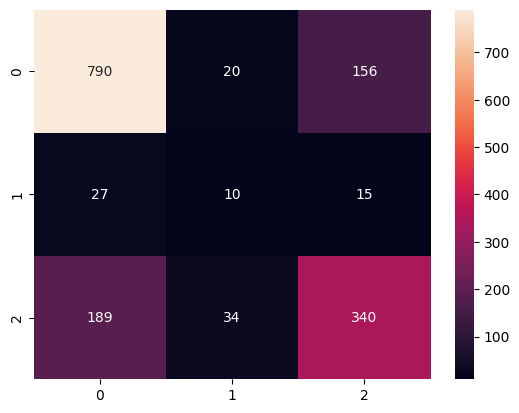

In [22]:
# Train model
tree = DecisionTreeClassifier()
tree.fit(x_train, y_train)

# Prediction
y_pred = tree.predict(x_test)
y_proba = tree.predict_proba(x_test)

# Classification report
tree_report = metrics.classification_report(y_test, y_pred, zero_division=0)
tree_accuracy = metrics.accuracy_score(y_test, y_pred)
print(tree_report)
print("Model aniqligi:", tree_accuracy)

# Log Loss
print("Log Loss:", metrics.log_loss(y_test, y_proba, labels=[0, 1, 2]))


# Consufion Matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt="g")
plt.show()

              precision    recall  f1-score   support

           C       0.82      0.93      0.87       966
          CL       0.67      0.08      0.14        52
           D       0.83      0.70      0.76       563

    accuracy                           0.82      1581
   macro avg       0.77      0.57      0.59      1581
weighted avg       0.82      0.82      0.81      1581

Model aniqligi: 0.8197343453510436
Log Loss: 0.0


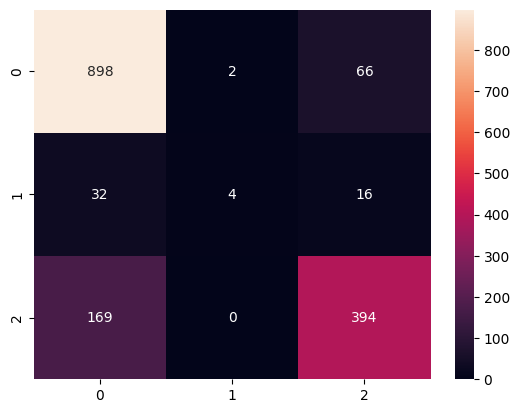

In [23]:
# Train model
rf_model = RandomForestClassifier()
rf_model.fit(x_train, y_train)

# Prediction
y_pred = rf_model.predict(x_test)
y_proba = rf_model.predict_proba(x_test)

# Classification report
rf_model_report = metrics.classification_report(y_test, y_pred, zero_division=0)
rf_model_accuracy = metrics.accuracy_score(y_test, y_pred)
print(rf_model_report)
print("Model aniqligi:", rf_model_accuracy)

# Log Loss
print("Log Loss:", metrics.log_loss(y_test, y_proba, labels=[0, 1, 2]))


# Consufion Matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt="g")
plt.show()

In [24]:
# Report

# Linear Regression
print("Linear Regression results")
print(lr_model_report)
print("Model aniqliligi:",lr_model_accuracy)

# SVM
print("Support Vector Machine results")
print(svm_report)
print("Model aniqliligi:", svm_accuracy)

# Decision Tree
print("Decision Tree results")
print(tree_report)
print("Model aniqliligi:", tree_accuracy)

# Rain Forest
print("Rain Forest results")
print(rf_model_report)
print("Model aniqliligi:", rf_model_accuracy)

Linear Regression results
              precision    recall  f1-score   support

           C       0.79      0.91      0.85       966
          CL       0.00      0.00      0.00        52
           D       0.78      0.64      0.70       563

    accuracy                           0.79      1581
   macro avg       0.52      0.52      0.52      1581
weighted avg       0.76      0.79      0.77      1581

Model aniqliligi: 0.7862112586970272
Support Vector Machine results
              precision    recall  f1-score   support

           C       0.81      0.92      0.86       966
          CL       0.50      0.02      0.04        52
           D       0.79      0.68      0.73       563

    accuracy                           0.80      1581
   macro avg       0.70      0.54      0.54      1581
weighted avg       0.79      0.80      0.79      1581

Model aniqliligi: 0.8020240354206198
Decision Tree results
              precision    recall  f1-score   support

           C       0.79      0

In [25]:
df_test = pd.read_csv('test2.csv')

ids = df_test['id']
sub = df_test.drop('id', axis = 1)
df_test_prepared = proc.transform(sub)

y_probs = rf_model.predict_proba(df_test_prepared)

# Ehtimolliklarni cheklash
y_probs = np.clip(y_probs, 1e-15, 1 - 1e-15)

encoded_classes = l_en.classes_
# Natijalar quyidagicha tartibda saqlanadi - array(['C', 'CL', 'D'], dtype=object)

In [26]:
submission_df = pd.DataFrame({'id': ids})

In [27]:
desired_columns_map = {
    'C': 'Status_C',
    'CL': 'Status_CL',
    'D': 'Status_D'
}

In [28]:
if y_probs.shape[1] != len(encoded_classes):
    print("Xatolik: Ehtimolliklar ustunlari soni klasslar soniga mos kelmayapti!")
else:
    for i, class_label in enumerate(encoded_classes):
        # class_label bu 'C', 'CL', 'D' kabi qiymat
        # Agar 'Status C' kabi aniq nomlar kerak bo'lsa va class_label ('C', 'CL', 'D') shularga mos kelsa:
        if class_label in desired_columns_map:
            column_name = desired_columns_map[class_label]
            submission_df[column_name] = y_probs[:, i]
        else:
            # Agar l_en.classes_ da kutilmagan qiymat bo'lsa, umumiy nom beramiz
            # Yoki xatolik haqida xabar berish mumkin
            print(f"Ogohlantirish: '{class_label}' uchun maxsus ustun nomi topilmadi. 'Status_{class_label}' ishlatiladi.")
            submission_df[f'Status_{class_label}'] = y_probs[:, i]

In [29]:
submission_filename = 'submission_probabilities.csv'
submission_df.to_csv(submission_filename, index=False)

In [30]:
print(f"\nNatijalar '{submission_filename}' fayliga saqlandi.")
print(submission_df.head())


Natijalar 'submission_probabilities.csv' fayliga saqlandi.
     id  Status_C     Status_CL  Status_D
0  7905      0.70  3.000000e-02      0.27
1  7906      0.76  1.200000e-01      0.12
2  7907      0.20  3.000000e-02      0.77
3  7908      0.95  1.000000e-15      0.05
4  7909      0.63  1.300000e-01      0.24


In [31]:
submission_df.head()

,id,Status_C,Status_CL,Status_D
0,7905,0.70,3.000000e-02,0.27
1,7906,0.76,1.200000e-01,0.12
2,7907,0.20,3.000000e-02,0.77
3,7908,0.95,1.000000e-15,0.05
4,7909,0.63,1.300000e-01,0.24
